In [1]:
import pandas as pd
from src.assay_calibration.data_utils.dataset import Scoreset
from src.assay_calibration.fit_utils.two_sample import density_utils
from tqdm.auto import tqdm
import sys
sys.path.append("..")
from src.assay_calibration.fit_utils.fit import (Fit,calculate_score_thresholds, thresholds_from_prior)
from pathlib import Path
import numpy as np
import logging
logging.getLogger('matplotlib').setLevel(logging.ERROR)
pd.set_option("display.max_columns",None)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/data/dzeiberg/pillar_project/pillar_project_data/dataset_09192025/final_pillar_data_with_clinvar_gnomad_wREVEL_wAM_wspliceAI_wMutpred2_wtrainvar_expanded_091125.csv")

/tmp/ipykernel_1279934/2503977347.py:1: DtypeWarning: Columns (4,11,22,23,24,31,35,36,37,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,57,69,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/data/dzeiberg/pillar_project/pillar_project_data/dataset_09192025/final_pillar_data_with_clinvar_gnomad_wREVEL_wAM_wspliceAI_wMutpred2_wtrainvar_expanded_091125.csv")


- all variants
- all nsSNV
- all missense nsSNV
- all gnomAD
- all gnomAD nsSNV
- all gnomAD missense nsSNV

In [3]:
ddx3x_df = df[df.Dataset == "DDX3X_Radford_2023_cLFC_day15"]
ddx3x_scoresets = {population_type : Scoreset(ddx3x_df,
                                              population_type=population_type) for population_type in tqdm(['all_variants',
                                                                                                       'all_nsSNV',
                                                                                                       'all_missense_nsSNV',
                                                                                                       'gnomAD',
                                                                                                       'gnomAD_nsSNV',
                                                                                                       'gnomAD_missense_nsSNV'])}

  0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:

# N_restarts=100
# num_bootstrap_iters=5
# jobs = []
# for population_name, scoreset in ddx3x_scoresets.items():
#     fit = Fit(scoreset)
#     save_dir = Path("test") / "test_fits" / scoreset.scoreset_name / population_name
#     if save_dir.exists() and any(save_dir.iterdir()):
#         for file in save_dir.iterdir():
#             file.unlink()
#     save_dir.mkdir(exist_ok=True,parents=True)
#     scoreset_jobs = sum([fit.generate_fit_jobs([2,3],
#                                     save_dir,
#                                     bootstrap_seed=fit_num,
#                                     num_fits=N_restarts) \
#                     for fit_num in range(num_bootstrap_iters)],[])
#     jobs += scoreset_jobs

# import pickle
# from joblib import Parallel, delayed
# from pathlib import Path
# job_savedir = Path("test/jobs/")
# job_savedir.mkdir(parents=True,exist_ok=True)
# Parallel(n_jobs=-1, verbose=100)(
#     delayed(lambda jobNum, job: pickle.dump(job, open(job_savedir / f"job_{jobNum}.pkl", "wb")))(jobNum, job)
#     for jobNum, job in enumerate(jobs)
# )

In [ ]:
# Parallel(n_jobs=-1,verbose=100)(delayed(Fit.execute_fit_job)(job) for job in jobs)

In [4]:
from pathlib import Path
import json
from joblib import Parallel, delayed
def process_fit(population_type,fit_filepath):
    with open(fit_filepath) as f:
        fit = json.load(f)
    fit['fit']['weights'] = np.array(fit['fit']['weights'])
    return ((population_type,fit['bootstrap_seed']),fit)

fits_dir = Path("test/test_fits/DDX3X_Radford_2023_cLFC_day15/")
processed_fits = Parallel(n_jobs=-1, verbose=100)(delayed(process_fit)(population_type, fit_file) \
                                                  for population_type in ddx3x_scoresets.keys() \
                                                    for fit_file in tqdm((fits_dir / population_type).glob("*.json")))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 128 concurrent workers.


0it [00:00, ?it/s]

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    2.2s
[Paralle

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 131 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 132 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 133 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 134 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 135 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 137 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 139 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 140 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 141 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 143 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 144 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 145 tasks      | elapsed:    2.8s
[Paralle

In [5]:
sorted_processed_fits = sorted(processed_fits, key=lambda tup: -tup[1]['val_ll']) # type: ignore
scoreset_fits = {population_type: dict() for population_type in ddx3x_scoresets.keys()}
for (population_type, bootstrap_index), fit in sorted_processed_fits:
    if bootstrap_index not in scoreset_fits[population_type]:
        scoreset_fits[population_type][bootstrap_index] = fit
scoreset_fits = {k : list(d.values()) for k,d in scoreset_fits.items()}


In [6]:
len(scoreset_fits['all_variants'])

4

In [ ]:


# scoreset_fits = {}
# for population_type in tqdm(ddx3x_scoresets.keys()):
#     fits_dir = Path("test/test_fits/DDX3X_Radford_2023_cLFC_day15/") / population_type
#     seed_to_best_fit = {}
#     for fit_file in tqdm(fits_dir.glob("*.json"),leave=False):
#         # read the fit
#         with open(fit_file) as f:
#             fit = json.load(f)
#         # get the bootstrap seed
#         bootstrap_seed = fit['bootstrap_seed']
#         # save the fit if it is the first fit for this seed
#         if bootstrap_seed not in seed_to_best_fit:
#             fit['fit']['weights'] = np.array(fit['fit']['weights'])
#             seed_to_best_fit[bootstrap_seed] = fit
#             continue
#         # save the fit if it has a better log likelihood than the previous best fit
#         if seed_to_best_fit[bootstrap_seed]['val_ll'] < fit['val_ll']:
#             fit['fit']['weights'] = np.array(fit['fit']['weights'])
#             seed_to_best_fit[bootstrap_seed] = fit
#     fits = list(seed_to_best_fit.values())
#     scoreset_fits[population_type] = fits

In [ ]:
def tryToGetPrior(fit,population_name):
    scoreset = ddx3x_scoresets[population_name]
    scores = scoreset.scores
    sample_assignment = scoreset.sample_assignments
    population_sample = scores[sample_assignment[:,2]]
    try:
        prior = Fit.from_dict(scoreset,fit['fit']).get_prior_estimate(population_sample,
                                                         tolerance=1e-5)
    except ValueError as e:
        print(e)
        prior = np.nan
    return prior

In [ ]:
population_priors = {population_name: [tryToGetPrior(fit,population_name) for fit in tqdm(population_fits,leave=False)] \
                        for population_name,population_fits in tqdm(scoreset_fits.items())}

In [ ]:
figdims = np.array([ddx3x_scoresets['gnomAD'].sample_assignments.shape[1],
                    len(ddx3x_scoresets)])
fig,ax = plt.subplots(*figdims, figsize=np.array((5,3)) * figdims,sharex=True,sharey='row')

for scoresetNum,((population_type,scoreset),scoresetAx) in enumerate(zip(ddx3x_scoresets.items(),
                                                                         ax.T)):
    scoreset_fit = scoreset_fits[population_type]
    for i,(sample_scores, sample_name) in enumerate(scoreset.samples):
        score_range = np.linspace(sample_scores.min(),sample_scores.max(),1000)
        sns.histplot(sample_scores, ax=scoresetAx[i],stat='density',label=f"n={len(sample_scores):,d}")
        scoresetAx[i].set_title(sample_name.replace("population",scoreset.population_type))
        pdf = np.stack([density_utils.joint_densities(score_range,
                                            fit['fit']['component_params'],
                                            fit['fit']['weights'][i]).sum(0) for fit in scoreset_fit])
        
        scoresetAx[i].plot(score_range, np.median(pdf,axis=0),color='C1')
        scoresetAx[i].legend()
        scoresetAx[i].fill_between(score_range, *np.percentile(pdf,[2.5,97.5],axis=0),color='C1',alpha=.5)
    population_idx = [i for i,name in enumerate(scoreset.sample_names) if name in {'population',population_type}][0]
    scoresetAx[population_idx].set_title(f"{scoreset.population_type}\nprior: {np.median(population_priors[population_type]):.3f}")

# fig.suptitle(ddx3x_scoresets['all_missense_snv'].scoreset_name)

In [ ]:
thresholds = {}
def replace_inf(arr, replaceVal):
    arr[np.isinf(arr)] = replaceVal
    return arr
fig,ax = plt.subplots(len(ddx3x_scoresets),1,figsize=(6,12),sharey=True,sharex=True)
for i,(population_type, scoreset) in enumerate(ddx3x_scoresets.items()):
    score_range= np.linspace(*np.percentile(scoreset.scores,[0,100]),1000)
    scoreset_fit = scoreset_fits[population_type]
    pathogenic_log_pdf = np.stack([np.log(density_utils.joint_densities(score_range,
                                                                 fit['fit']['component_params'],
                                                                 fit['fit']['weights'][0]).sum(0)) \
                                            for fit in scoreset_fit])
    benign_log_pdf = np.stack([np.log(density_utils.joint_densities(score_range,
                                                                 fit['fit']['component_params'],
                                                                 fit['fit']['weights'][1]).sum(0))\
                                            for fit in scoreset_fit])
    log_lrPlus = pathogenic_log_pdf - benign_log_pdf
    pathogenic_thresholds, benign_thresholds = calculate_score_thresholds(np.percentile(log_lrPlus,5,axis=0),
                                                                          np.percentile(log_lrPlus,95,axis=0),
                                                                          np.median(population_priors[population_type]),
                                                                          score_range,
                                                                          [1,2,3,4,8],
                                                                          False)
    thresholds[population_type] = dict(pathogenic=pathogenic_thresholds,
                                       benign=benign_thresholds)
    ax[i].plot(score_range, np.median(log_lrPlus,axis=0))
    ax[i].fill_between(score_range, *np.percentile(log_lrPlus,[2.5,97.5],axis=0),alpha=.5)
    
    

In [ ]:
pathogenic_log_pdf, benign_log_pdf

In [ ]:
np.stack([replace_inf(density_utils.log_joint_densities(score_range,
                                                                 fit['fit']['component_params'],
                                                                 fit['fit']['weights'][1]),0).sum(0)\
                                            for fit in scoreset_fit])

In [ ]:
{popType : np.median(popPriors) for popType, popPriors in population_priors.items()}

In [ ]:
thresholds

In [ ]:
pd.DataFrame.from_dict({population_type: dict(zip([1,2,3,4,8],popThr['pathogenic'])) for population_type,popThr in thresholds.items()},
                       orient='index')

In [7]:
def get_fit_lrPlus(fit):
    params = fit['component_params']
    weights = fit['weights']
    xrange = np.linspace(*fit['xlims'],1000)
    lr_plus = density_utils.mixture_pdf(xrange,params,weights[0]) - density_utils.mixture_pdf(xrange,params,weights[1])
    return xrange, lr_plus

In [9]:
scoreset_fits['all_variants'][0]

{'scoreset_name': 'DDX3X_Radford_2023_cLFC_day15',
 'bootstrap_seed': 2,
 'num_components': 3,
 'fit_idx': 9,
 'fit': {'component_params': [[-21.4643503690711,
    -0.26080976472120365,
    2.0181418370643156],
   [-0.04096730164841177, 0.00840358314031472, 0.13091907494508737],
   [1.4051543890052127, 0.23039973204096104, 0.22930534363221933]],
  'weights': array([[0.83844147, 0.12886517, 0.03269337],
         [0.        , 1.        , 0.        ],
         [0.21326913, 0.63816632, 0.14856455],
         [0.00747341, 0.98659171, 0.00593488]]),
  'likelihoods': [-0.6030606054398234,
   -0.49233241333489025,
   -0.4722073769116105,
   -0.46869812199626354,
   -0.46773498856512424,
   -0.4672081858973432,
   -0.46678200001890685,
   -0.46640507086397875,
   -0.46606726925915026,
   -0.4657542838643359,
   -0.4654583177898469,
   -0.46517695482012655,
   -0.46490802611158916,
   -0.4646501596061864,
   -0.46440233759917987,
   -0.46416372984867565,
   -0.4639336231106637,
   -0.463715256438

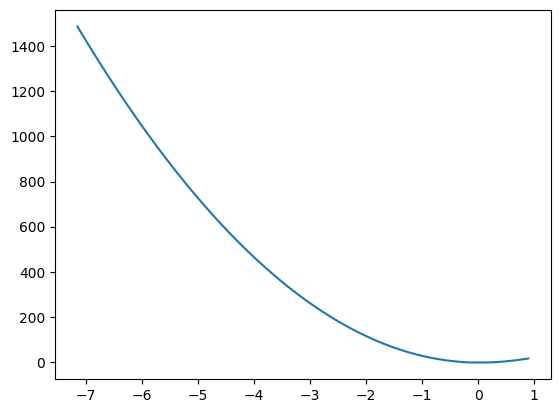

In [10]:
plt.plot(*get_fit_lrPlus(scoreset_fits['all_variants'][0]['fit']))

In [ ]:
scoreset_fits['all_nsSNV'][0]['fit']['xlims']